In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [4]:
# Load complete dataset
df = pd.read_csv("data.csv")

# Random sample for the project
df = df.sample(n=100000, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)
df.head()

/tmp/ipykernel_592/442187411.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv")


Dataset Shape: (100000, 18)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2.0,2020-01-17 18:18:36,2020-01-17 18:46:24,1.0,3.60,1.0,N,264,264,1.0,18.5,1.0,0.5,4.56,0.0,0.3,27.36,2.5
1,2.0,2020-01-25 10:49:58,2020-01-25 11:07:35,1.0,3.28,1.0,N,142,246,1.0,14.0,0.0,0.5,1.70,0.0,0.3,19.00,2.5
2,2.0,2020-01-15 07:30:08,2020-01-15 07:40:01,1.0,1.75,1.0,N,238,166,1.0,8.5,0.0,0.5,1.20,0.0,0.3,13.00,2.5
3,2.0,2020-01-09 06:29:09,2020-01-09 06:35:44,1.0,0.87,1.0,N,100,164,2.0,5.5,0.0,0.5,0.00,0.0,0.3,8.80,2.5
4,2.0,2020-01-26 12:24:04,2020-01-26 12:29:15,2.0,0.98,1.0,N,161,43,2.0,5.5,0.0,0.5,0.00,0.0,0.3,8.80,2.5


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows : 100000
Columns : 18

Column Names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge']

Data Types:
VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
VendorID,98965.0,NaN,NaN,NaN,1.669004,0.470574,1.0,1.0,2.0,2.0,2.0
tpep_pickup_datetime,100000,97585,2020-01-25 20:26:47,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tpep_dropoff_datetime,100000,97613,2020-01-21 12:26:06,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passenger_count,98965.0,NaN,NaN,NaN,1.517072,1.155577,0.0,1.0,1.0,2.0,9.0
trip_distance,100000.0,NaN,NaN,NaN,2.910405,3.813423,-21.94,0.97,1.6,2.95,61.0
RatecodeID,98965.0,NaN,NaN,NaN,1.061678,0.899094,1.0,1.0,1.0,1.0,99.0
store_and_fwd_flag,98965,2,N,97886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,100000.0,NaN,NaN,NaN,164.62756,65.579617,1.0,132.0,162.0,234.0,265.0
DOLocationID,100000.0,NaN,NaN,NaN,162.30729,69.922916,1.0,113.0,162.0,234.0,265.0
payment_type,98965.0,NaN,NaN,NaN,1.272935,0.476656,1.0,1.0,1.0,2.0,4.0


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

display(missing)

print("Duplicate Records:", df.duplicated().sum())

,Missing Values,Percentage
VendorID,1035,1.03
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,1035,1.03
trip_distance,0,0.00
RatecodeID,1035,1.03
store_and_fwd_flag,1035,1.03
PULocationID,0,0.00
DOLocationID,0,0.00
payment_type,1035,1.03


Duplicate Records: 2


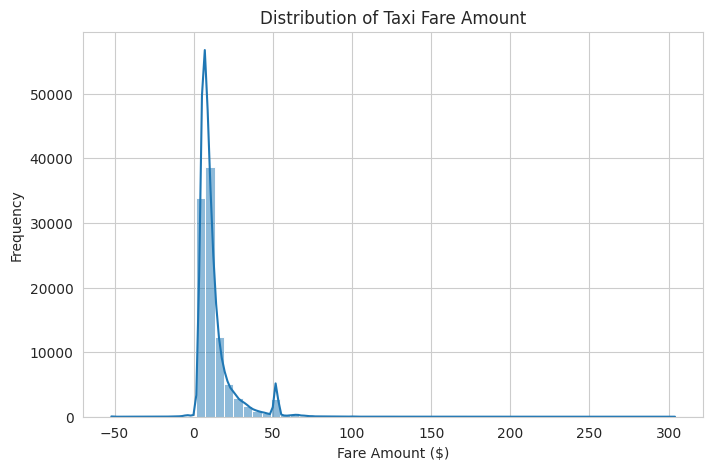

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["fare_amount"], bins=60, kde=True)
plt.title("Distribution of Taxi Fare Amount")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")
plt.show()

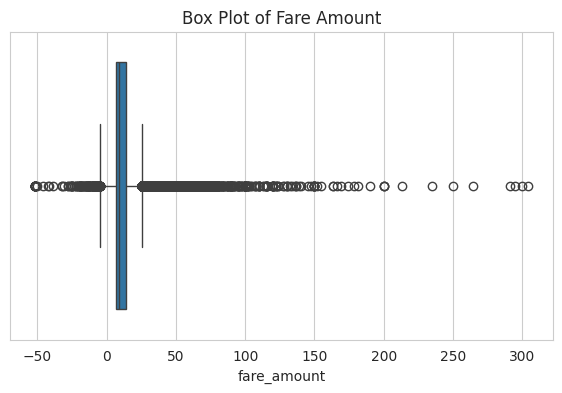

In [9]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["fare_amount"])
plt.title("Box Plot of Fare Amount")
plt.show()

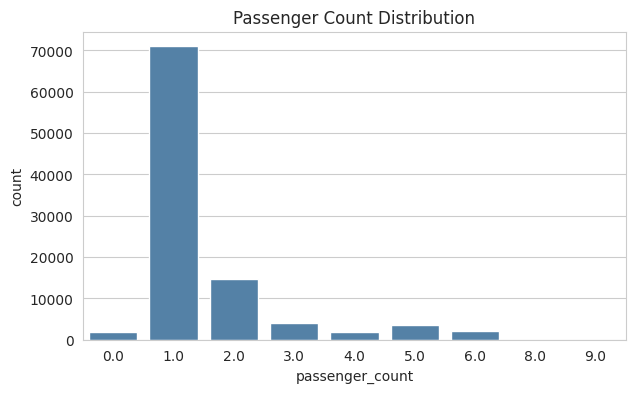

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="passenger_count", color="steelblue")
plt.title("Passenger Count Distribution")
plt.show()

In [11]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day"] = df["tpep_pickup_datetime"].dt.day
df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_name()
df["month"] = df["tpep_pickup_datetime"].dt.month_name()
df["weekend"] = df["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,hour,day,day_of_week,month,weekend
0,2.0,2020-01-17 18:18:36,2020-01-17 18:46:24,1.0,3.60,1.0,N,264,264,1.0,...,4.56,0.0,0.3,27.36,2.5,18,17,Friday,January,0
1,2.0,2020-01-25 10:49:58,2020-01-25 11:07:35,1.0,3.28,1.0,N,142,246,1.0,...,1.70,0.0,0.3,19.00,2.5,10,25,Saturday,January,1
2,2.0,2020-01-15 07:30:08,2020-01-15 07:40:01,1.0,1.75,1.0,N,238,166,1.0,...,1.20,0.0,0.3,13.00,2.5,7,15,Wednesday,January,0
3,2.0,2020-01-09 06:29:09,2020-01-09 06:35:44,1.0,0.87,1.0,N,100,164,2.0,...,0.00,0.0,0.3,8.80,2.5,6,9,Thursday,January,0
4,2.0,2020-01-26 12:24:04,2020-01-26 12:29:15,2.0,0.98,1.0,N,161,43,2.0,...,0.00,0.0,0.3,8.80,2.5,12,26,Sunday,January,1


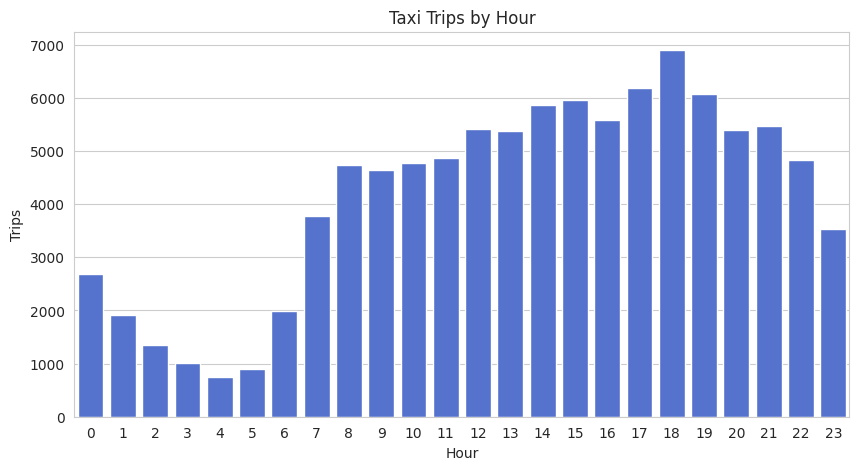

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="hour", color="royalblue")
plt.title("Taxi Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

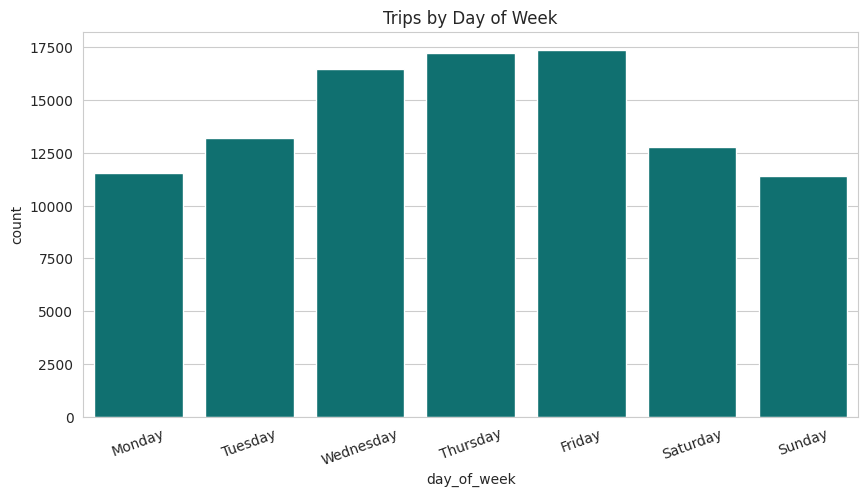

In [13]:
order = ["Monday","Tuesday","Wednesday","Thursday",
         "Friday","Saturday","Sunday"]

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="day_of_week", order=order, color="teal")
plt.title("Trips by Day of Week")
plt.xticks(rotation=20)
plt.show()

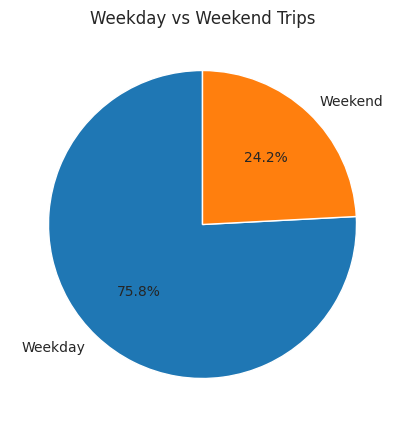

In [14]:
counts = df["weekend"].value_counts().reindex([0,1], fill_value=0)

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=["Weekday","Weekend"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Weekday vs Weekend Trips")
plt.show()

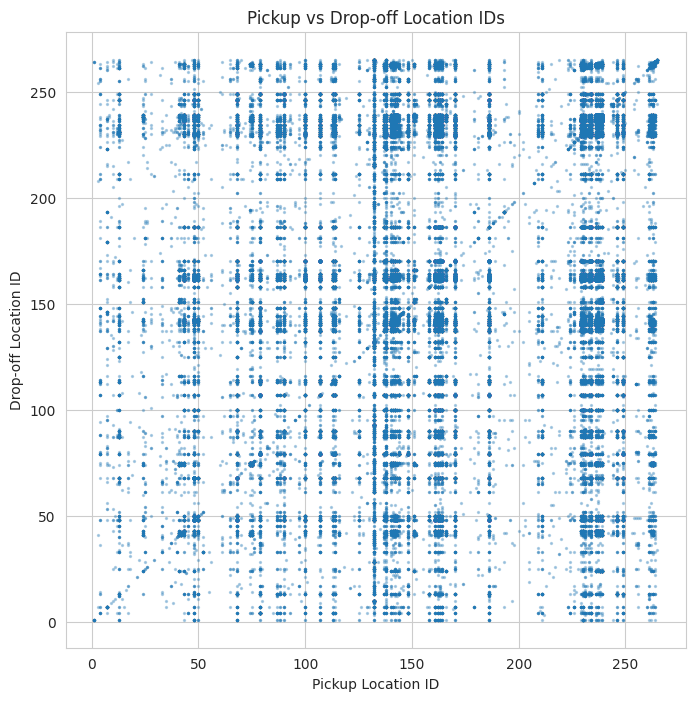

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(
    df["PULocationID"],
    df["DOLocationID"],
    s=2,
    alpha=0.3
)

plt.title("Pickup vs Drop-off Location IDs")
plt.xlabel("Pickup Location ID")
plt.ylabel("Drop-off Location ID")
plt.show()

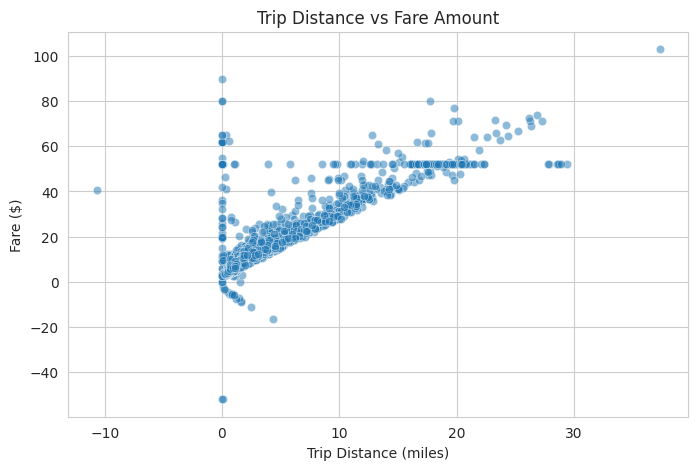

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="trip_distance",
    y="fare_amount",
    alpha=0.5
)

plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare ($)")
plt.show()

In [17]:
print("Negative fares :", (df["fare_amount"] < 0).sum())
print("Zero fares     :", (df["fare_amount"] == 0).sum())
print("Zero distance  :", (df["trip_distance"] == 0).sum())
print("Passenger = 0  :", (df["passenger_count"] == 0).sum())

Negative fares : 320
Zero fares     : 42
Zero distance  : 1066
Passenger = 0  : 1782


In [18]:
df_clean = df.copy()

df_clean = df_clean[
    (df_clean["fare_amount"] > 0) &
    (df_clean["trip_distance"] > 0) &
    (df_clean["passenger_count"] > 0)
]

print("Original shape :", df.shape)
print("Cleaned shape  :", df_clean.shape)

Original shape : (100000, 23)
Cleaned shape  : (95848, 23)


In [19]:
df_clean["rush_hour"] = (
    ((df_clean["hour"] >= 7) & (df_clean["hour"] <= 10)) |
    ((df_clean["hour"] >= 16) & (df_clean["hour"] <= 19))
).astype(int)

df_clean[["hour","rush_hour"]].head()

,hour,rush_hour
0,18,1
1,10,1
2,7,1
3,6,0
4,12,0


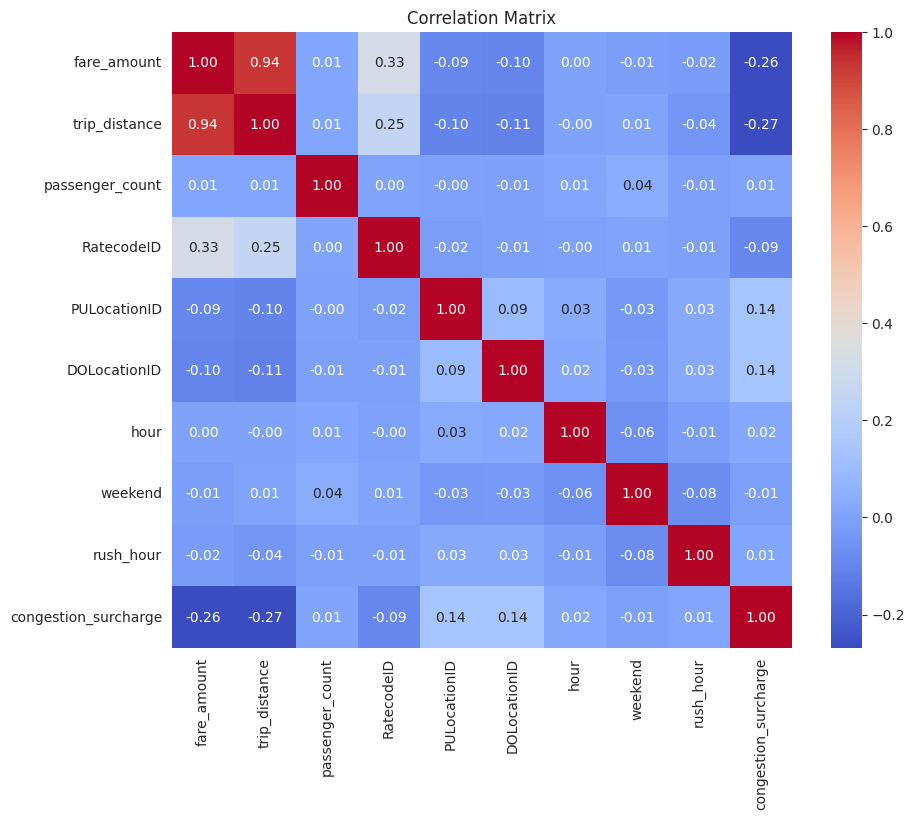

In [20]:
plt.figure(figsize=(10,8))

corr = df_clean[
    ["fare_amount","trip_distance","passenger_count",
     "RatecodeID","PULocationID","DOLocationID",
     "hour","weekend","rush_hour","congestion_surcharge"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [21]:
features = [
    "trip_distance",
    "passenger_count",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "hour",
    "weekend",
    "rush_hour",
    "congestion_surcharge"
]

X = df_clean[features]
y = df_clean["fare_amount"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (95848, 9)
Target: (95848,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (76678, 9)
Testing : (19170, 9)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [24]:
pd.DataFrame(
    X_train_scaled,
    columns=features
).head()

,trip_distance,passenger_count,RatecodeID,PULocationID,DOLocationID,hour,weekend,rush_hour,congestion_surcharge
0,-0.645798,-0.476013,-0.145504,-1.146140,-1.041435,-0.832033,-0.564850,1.155993,0.269128
1,-0.667204,-0.476013,-0.145504,1.242508,1.198002,-0.151422,1.770382,-0.865057,0.269128
2,-0.145442,1.259877,-0.145504,0.017561,-1.271121,-0.151422,-0.564850,-0.865057,-3.715776
3,0.413780,-0.476013,-0.145504,1.502810,0.882184,0.699342,1.770382,1.155993,0.269128
4,-0.426391,-0.476013,-0.145504,-0.058998,1.068804,-2.363409,-0.564850,-0.865057,0.269128


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [26]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    return [mae, mse, rmse, r2]

In [27]:
results = pd.DataFrame(
    columns=["MAE","MSE","RMSE","R2"],
    index=["Linear Regression","Decision Tree","Random Forest"]
)

results.loc["Linear Regression"] = evaluate_model(
    LinearRegression(),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.loc["Decision Tree"] = evaluate_model(
    DecisionTreeRegressor(random_state=42),
    X_train,
    X_test,
    y_train,
    y_test
)

results.loc["Random Forest"] = evaluate_model(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_train,
    X_test,
    y_train,
    y_test
)

results

,MAE,MSE,RMSE,R2
Linear Regression,1.868057,82.231084,9.068136,0.353245
Decision Tree,1.583451,10.167709,3.188685,0.92003
Random Forest,1.175014,6.144581,2.478827,0.951672


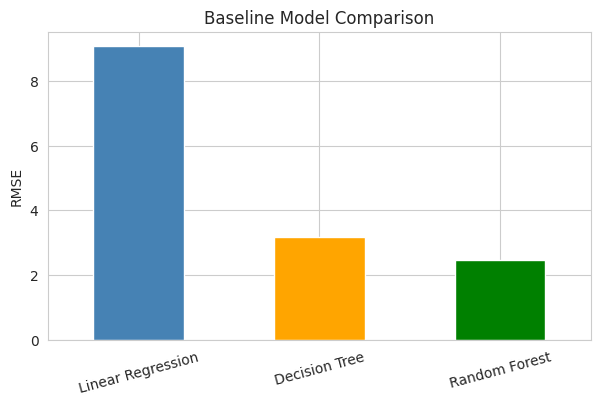

In [28]:
plt.figure(figsize=(7,4))

results["RMSE"].astype(float).plot(
    kind="bar",
    color=["steelblue","orange","green"]
)

plt.ylabel("RMSE")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=15)

plt.show()

In [29]:
!pip -q install tensorflow

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 24.6637 - mae: 2.7043 - val_loss: 7.9156 - val_mae: 1.4190
Epoch 2/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 11.0469 - mae: 1.8347 - val_loss: 8.6427 - val_mae: 1.4213
Epoch 3/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 10.2781 - mae: 1.7471 - val_loss: 7.6469 - val_mae: 1.3631
Epoch 4/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10.2791 - mae: 1.6931 - val_loss: 7.7109 - val_mae: 1.3699
Epoch 5/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.3920 - mae: 1.6403 - val_loss: 6.7893 - val_mae: 1.2955
Epoch 6/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.4795 - mae: 1.6144 - val_loss: 7.4832 - val_mae: 1.4048
Epoch 7/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.1061 - mae: 1.5860 - val_loss: 6.3326 - val_mae: 1.3106
Epoch 8/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.8160 - mae: 1.5661 - val_loss: 6.4015 - val_mae: 1.3176
Epoch 9/100
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 

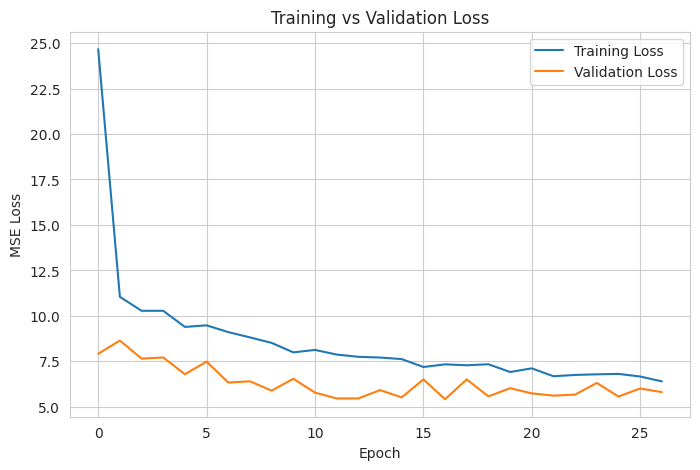

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.show()

In [34]:
pred_nn = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, pred_nn)
mse = mean_squared_error(y_test, pred_nn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_nn)

print("MAE :", round(mae,3))
print("MSE :", round(mse,3))
print("RMSE:", round(rmse,3))
print("R²  :", round(r2,3))

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step
MAE : 1.525
MSE : 126.183
RMSE: 11.233
R²  : 0.008


In [35]:
results.loc["Deep Neural Network"] = [mae, mse, rmse, r2]
results

,MAE,MSE,RMSE,R2
Linear Regression,1.868057,82.231084,9.068136,0.353245
Decision Tree,1.583451,10.167709,3.188685,0.92003
Random Forest,1.175014,6.144581,2.478827,0.951672
Deep Neural Network,1.524828,126.183378,11.233138,0.007556


In [36]:
from tensorflow.keras import regularizers

model = Sequential([
    Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001),
          input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,777 (171.00 KB)

 Trainable params: 43,777 (171.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 2.3957 - mae: 2.2415 - val_loss: 1.5186 - val_mae: 1.3910
Epoch 2/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.7810 - mae: 1.6712 - val_loss: 1.4369 - val_mae: 1.3418
Epoch 3/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.6566 - mae: 1.5731 - val_loss: 1.4557 - val_mae: 1.3808
Epoch 4/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.5999 - mae: 1.5323 - val_loss: 1.4172 - val_mae: 1.3552
Epoch 5/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.5544 - mae: 1.4962 - val_loss: 1.4086 - val_mae: 1.3541
Epoch 6/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.5343 - mae: 1.4815 - val_loss: 1.3358 - val_mae: 1.2845
Epoch 7/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.5332 - mae: 1.4831 - val_loss: 1.3258 - val_mae: 1.2768
Epoch 8/150
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.5151 - mae: 1.4671 - val_loss: 1.3428 - val_mae: 1.2965
Epoch 9/150
1917/1917 ━━━━━━━━━━

In [38]:
pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R²  :", round(r2,3))

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE : 1.375
RMSE: 10.097
R²  : 0.198


In [39]:
results.loc["Deep Neural Network"] = [mae, mse, rmse, r2]
results.sort_values("RMSE")

,MAE,MSE,RMSE,R2
Random Forest,1.175014,6.144581,2.478827,0.951672
Decision Tree,1.583451,10.167709,3.188685,0.92003
Linear Regression,1.868057,82.231084,9.068136,0.353245
Deep Neural Network,1.375202,101.959172,10.097483,0.198082


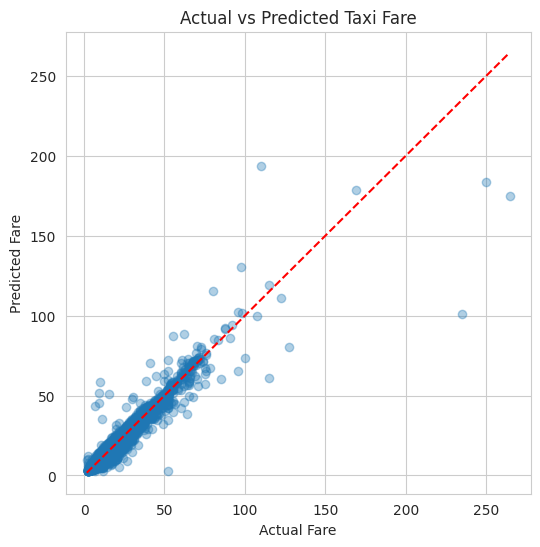

In [40]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred, alpha=0.35)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Taxi Fare")

plt.show()

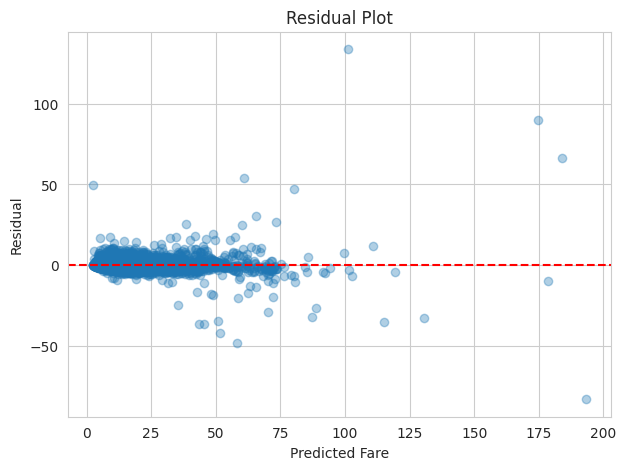

In [41]:
residuals = y_test - rf_pred

plt.figure(figsize=(7,5))

plt.scatter(rf_pred, residuals, alpha=0.35)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

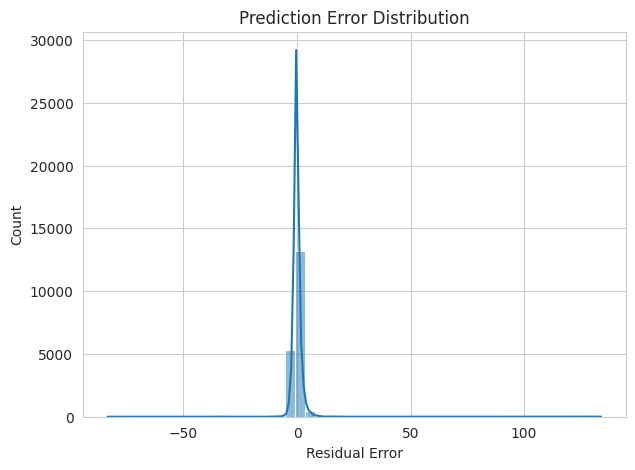

In [42]:
plt.figure(figsize=(7,5))

sns.histplot(residuals, bins=50, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Residual Error")

plt.show()

In [43]:
import joblib

joblib.dump(rf, "taxi_fare_random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [44]:
import joblib

# Load saved files
model = joblib.load("taxi_fare_random_forest.pkl")
scaler = joblib.load("scaler.pkl")

In [45]:
def predict_fare(trip_distance, passenger_count, ratecode,
                 pickup_id, dropoff_id, hour,
                 weekend, rush_hour, congestion):

    data = pd.DataFrame([{
        "trip_distance": trip_distance,
        "passenger_count": passenger_count,
        "RatecodeID": ratecode,
        "PULocationID": pickup_id,
        "DOLocationID": dropoff_id,
        "hour": hour,
        "weekend": weekend,
        "rush_hour": rush_hour,
        "congestion_surcharge": congestion
    }])

    prediction = model.predict(data)[0]
    return round(prediction, 2)

In [46]:
fare = predict_fare(
    trip_distance=4.8,
    passenger_count=2,
    ratecode=1,
    pickup_id=161,
    dropoff_id=230,
    hour=18,
    weekend=0,
    rush_hour=1,
    congestion=2.5
)

print("Estimated Taxi Fare: $", fare)

Estimated Taxi Fare: $ 19.88


In [47]:
print("="*40)
print("FINAL MODEL :", "Random Forest")
print("="*40)

print(results)

print("\nSelected Model: Random Forest")
print("Reason: Highest R² and Lowest RMSE")

FINAL MODEL : Random Forest
                          MAE         MSE       RMSE        R2
Linear Regression    1.868057   82.231084   9.068136  0.353245
Decision Tree        1.583451   10.167709   3.188685   0.92003
Random Forest        1.175014    6.144581   2.478827  0.951672
Deep Neural Network  1.375202  101.959172  10.097483  0.198082

Selected Model: Random Forest
Reason: Highest R² and Lowest RMSE


In [49]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "taxi_fare_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving taxi_fare_random_forest.pkl to taxi_fare_random_forest.pkl


In [4]:
# ==========================================
# NYC Taxi Fare Prediction - Gradio App
# ==========================================

!pip install -q gradio joblib

import gradio as gr
import pandas as pd
import joblib

# ----------------------------
# Load Trained Random Forest Model
# ----------------------------
model = joblib.load("taxi_fare_random_forest.pkl")

# ----------------------------
# Prediction Function
# ----------------------------
def predict_taxi_fare(
    trip_distance,
    passenger_count,
    ratecode,
    pickup_id,
    dropoff_id,
    trip_date,
    trip_time,
    congestion
):
    # Extract engineered features
    hour = int(trip_time.split(":")[0])

    date = pd.to_datetime(trip_date)
    weekend = 1 if date.weekday() >= 5 else 0

    rush_hour = 1 if (7 <= hour <= 10) or (16 <= hour <= 19) else 0

    input_df = pd.DataFrame([{
        "trip_distance": float(trip_distance),
        "passenger_count": int(passenger_count),
        "RatecodeID": int(ratecode),
        "PULocationID": int(pickup_id),
        "DOLocationID": int(dropoff_id),
        "hour": hour,
        "weekend": weekend,
        "rush_hour": rush_hour,
        "congestion_surcharge": float(congestion)
    }])

    prediction = model.predict(input_df)[0]

    return (
        f"$ {prediction:.2f}",
        f"Hour: {hour} | {'Weekend' if weekend else 'Weekday'} | "
        f"{'Rush Hour' if rush_hour else 'Non-Rush'}"
    )

# ----------------------------
# Custom CSS
# ----------------------------
css = """
.gradio-container{
    max-width:900px;
    margin:auto;
}
h1{
    text-align:center;
}
"""

# ----------------------------
# Gradio Interface
# ----------------------------
with gr.Blocks(css=css, title="NYC Taxi Fare Prediction") as demo:

    gr.Markdown("# 🚖 NYC Taxi Fare Prediction")

    gr.Markdown(
        "Enter the trip details below to estimate the taxi fare using the trained Random Forest model."
    )

    with gr.Row():

        with gr.Column():

            trip_distance = gr.Number(
                label="Trip Distance (miles)",
                value=4.8
            )

            passenger_count = gr.Slider(
                1, 8,
                value=2,
                step=1,
                label="Passenger Count"
            )

            ratecode = gr.Dropdown(
                [1,2,3,4,5,6],
                value=1,
                label="Rate Code"
            )

            congestion = gr.Dropdown(
                [0.0,2.5],
                value=2.5,
                label="Congestion Surcharge ($)"
            )

        with gr.Column():

            pickup_id = gr.Number(
                label="Pickup Location ID",
                value=161
            )

            dropoff_id = gr.Number(
                label="Drop-off Location ID",
                value=230
            )

            trip_date = gr.Textbox(
                label="Pickup Date (YYYY-MM-DD)",
                value="2020-02-15"
            )

            trip_time = gr.Textbox(
                label="Pickup Time (HH:MM)",
                value="18:30"
            )

    predict_btn = gr.Button("🚕 Predict Fare", variant="primary")

    fare = gr.Textbox(
        label="Estimated Taxi Fare"
    )

    details = gr.Textbox(
        label="Engineered Features"
    )

    predict_btn.click(
        fn=predict_taxi_fare,
        inputs=[
            trip_distance,
            passenger_count,
            ratecode,
            pickup_id,
            dropoff_id,
            trip_date,
            trip_time,
            congestion
        ],
        outputs=[fare, details]
    )

    gr.Markdown(
        """
        ---
        **Model:** Random Forest Regressor

        **Dataset:** NYC Taxi Fare Dataset

        This application internally generates the engineered features:
        - Hour
        - Weekend Indicator
        - Rush Hour Indicator
        """
    )

# ----------------------------
# Launch App
# ----------------------------
demo.launch(share=True)

/tmp/ipykernel_3253/1944213842.py:73: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=css, title="NYC Taxi Fare Prediction") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ee6f0b7829396729d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
